In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# Load model and data
model     = joblib.load("../data/models/xgboost_pm25.pkl")
explainer = joblib.load("../data/models/shap_explainer.pkl")
df        = pd.read_csv("../data/processed/master_features.csv")

FEATURE_COLS = [
    "aod_047_mean", "aod_055_mean", "aod_047_max",
    "no2_total_mean", "no2_trop_mean", "no2_total_max",
    "co_mean", "co_max",
    "latitude", "longitude",
    "lat_sin", "lat_cos", "lon_sin", "lon_cos",
    "is_igp", "is_coastal",
    "hour", "month", "day_of_week",
    "stubble_season", "is_rush_hour",
    "pm25_min", "pm25_max",
]

# Fill AOD NaN same as training
for col in ["aod_047_mean", "aod_055_mean", "aod_047_max"]:
    df[col] = df[col].fillna(df[col].median())

X = df[FEATURE_COLS]
shap_values = explainer.shap_values(X)

print(f"Loaded {len(df)} stations, {len(FEATURE_COLS)} features")
print(f"SHAP values shape: {shap_values.shape}")

✅ Loaded 464 stations, 23 features
SHAP values shape: (464, 23)


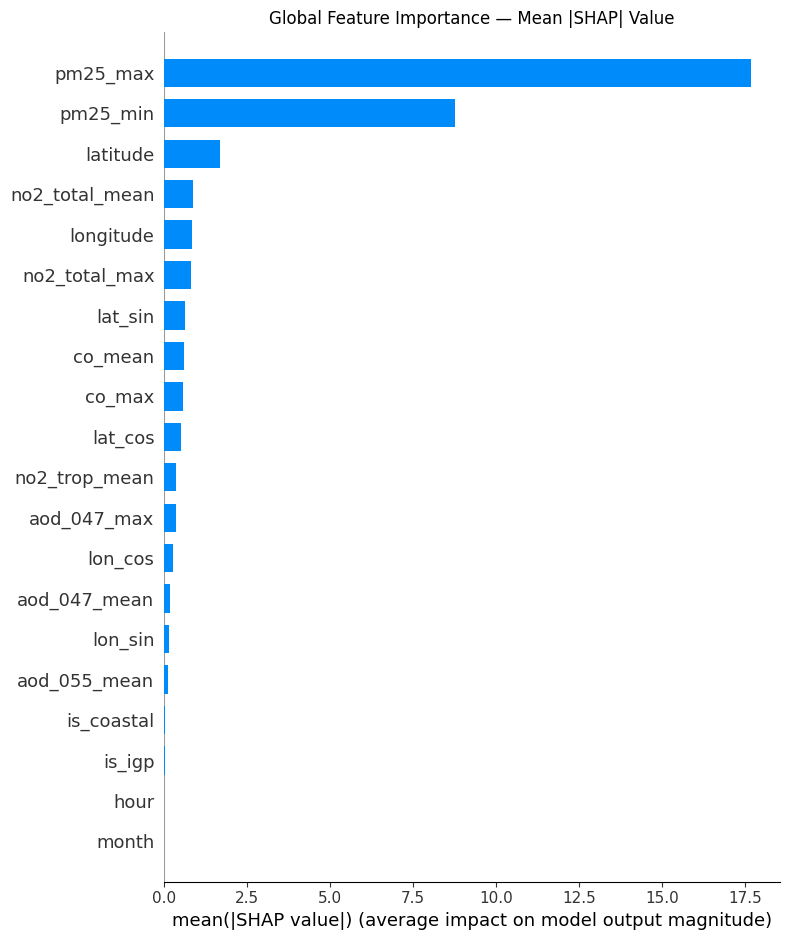

✅ Saved to docs/shap_global_importance.png


In [2]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("Global Feature Importance — Mean |SHAP| Value")
plt.tight_layout()
plt.savefig("../docs/shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

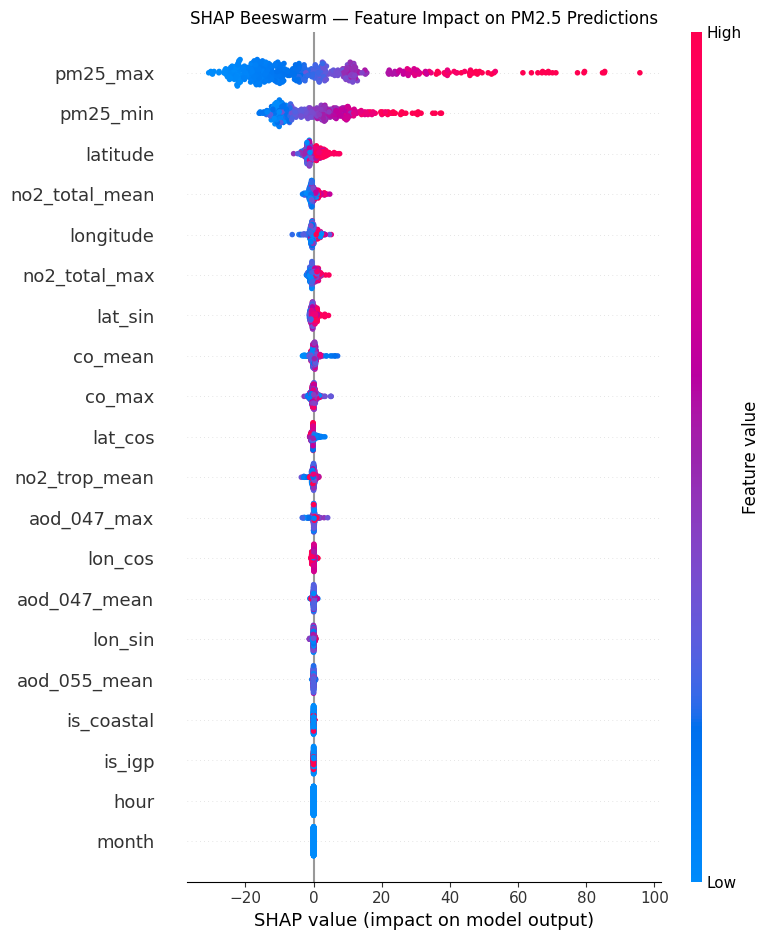

In [3]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, show=False)
plt.title("SHAP Beeswarm — Feature Impact on PM2.5 Predictions")
plt.tight_layout()
plt.savefig("../docs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

Most polluted station:
  Station:  Teri Gram, Gurugram - HSPCB
  City:     Gurugram, Haryana
  PM2.5:    238.0 µg/m³  (Very Poor)
  Predicted:204.9 µg/m³


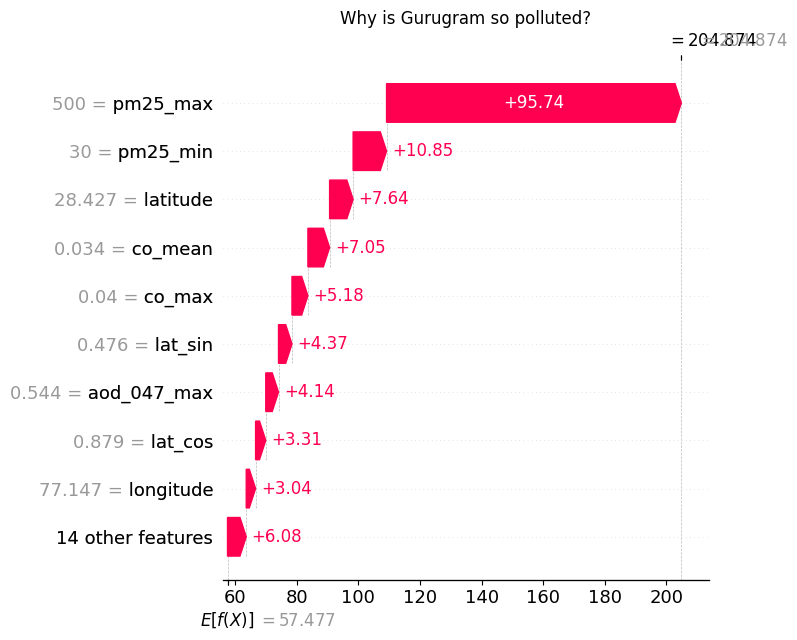

In [4]:
# Find most polluted station
worst_idx = df["pm25"].idxmax()
worst     = df.iloc[worst_idx]

print(f"Most polluted station:")
print(f"  Station:  {worst['station']}")
print(f"  City:     {worst['city']}, {worst['state']}")
print(f"  PM2.5:    {worst['pm25']} µg/m³  ({worst['aqi_category']})")
print(f"  Predicted:{model.predict(X.iloc[[worst_idx]])[0]:.1f} µg/m³")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[worst_idx],
        base_values=explainer.expected_value,
        data=X.iloc[worst_idx],
        feature_names=FEATURE_COLS
    ),
    show=False
)
plt.title(f"Why is {worst['city']} so polluted?")
plt.tight_layout()
plt.savefig("../docs/shap_waterfall_worst.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/_3/m9k4d4kj02v16q9dtcf14dzw0000gn/T/ipykernel_84129/2855512257.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([igp, non_igp], labels=["IGP Belt", "Rest of India"])


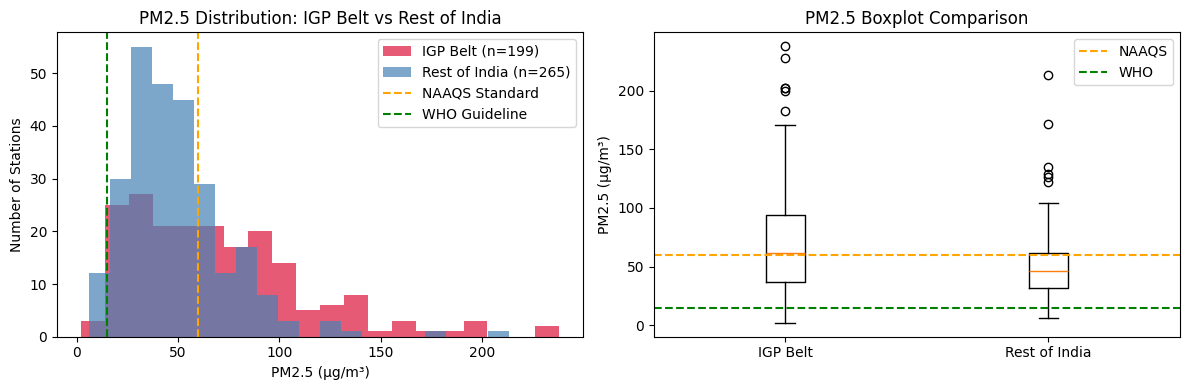

IGP mean PM2.5:     69.6 µg/m³
Non-IGP mean PM2.5: 49.6 µg/m³
IGP is 1.4x more polluted than rest of India


In [5]:
igp     = df[df["is_igp"] == 1]["pm25"]
non_igp = df[df["is_igp"] == 0]["pm25"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(igp,     bins=20, color="crimson",    alpha=0.7, label=f"IGP Belt (n={len(igp)})")
axes[0].hist(non_igp, bins=20, color="steelblue",  alpha=0.7, label=f"Rest of India (n={len(non_igp)})")
axes[0].axvline(60,  color="orange", linestyle="--", label="NAAQS Standard")
axes[0].axvline(15,  color="green",  linestyle="--", label="WHO Guideline")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Number of Stations")
axes[0].set_title("PM2.5 Distribution: IGP Belt vs Rest of India")
axes[0].legend()

axes[1].boxplot([igp, non_igp], labels=["IGP Belt", "Rest of India"])
axes[1].axhline(60, color="orange", linestyle="--", label="NAAQS")
axes[1].axhline(15, color="green",  linestyle="--", label="WHO")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("PM2.5 Boxplot Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/igp_vs_rest.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"IGP mean PM2.5:     {igp.mean():.1f} µg/m³")
print(f"Non-IGP mean PM2.5: {non_igp.mean():.1f} µg/m³")
print(f"IGP is {igp.mean()/non_igp.mean():.1f}x more polluted than rest of India")

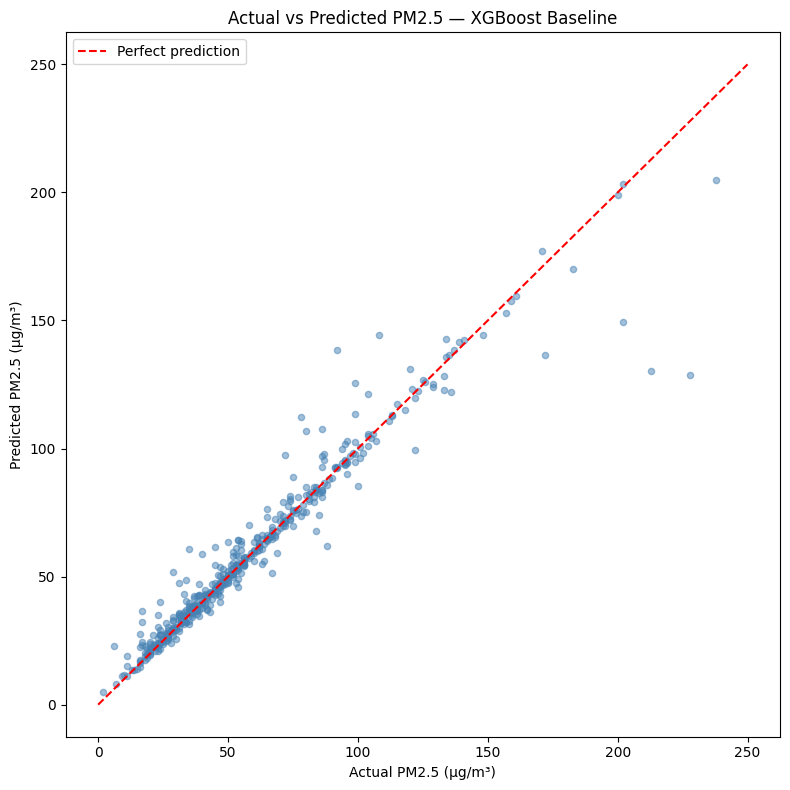

In [6]:
preds = model.predict(X)

plt.figure(figsize=(8, 8))
plt.scatter(df["pm25"], preds, alpha=0.5, color="steelblue", s=20)
plt.plot([0, 250], [0, 250], "r--", label="Perfect prediction")
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Actual vs Predicted PM2.5 — XGBoost Baseline")
plt.legend()
plt.tight_layout()
plt.savefig("../docs/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()